<center>
<img src="https://raw.githubusercontent.com/FUlyankin/r_probability/master/end_seminars_2020/sem08/real_expect.png" width="800">

# Домашнее задание 4: АБ-тест и рок-кривые
</center>

**ФИО:**
Хакимов Альберт Эдуардович

## Общая информация

__Дата выдачи:__ 14.03.2026

__Дедлайн:__ 23:59MSK 12.04.2026

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from collections import defaultdict
import pandas as pd

На семинаре мы попытались разобраться как устроена процедура АБ-тестирования. В этом задании мы попытаемся закрепить полученные знания и более аккуратно структурировать их.

### Кратко повторим теорию

Мы хотим выктить новую функциональность на сайте. Перед раскаткой нам хочется проверить, какой эффект мы оказываем на пользователя. Выделим две выборки: тестовую (treatment) и контрольную (control). Тестовой покажем новый сайт. Контрольной старый. Замерим инетерсующую нас метрику, нааример, время проведенной на сайте, в обеих группах:

$$
\begin{aligned}
&X^c_1, \ldots, X^c_{n_c} \sim iid (\mu_c, \sigma^2_c) \\
&X^t_1, \ldots, X^t_{n_t} \sim iid (\mu_t, \sigma^2_t)
\end{aligned}
$$

У выборок есть какие-то математические ожидания, дисперсии. Выборки собраны независимо друг от друга. Если их математические ожидания одинаковые, будем считать, что новая функциональность никак не повлияла на пользователей. Сформулируем это в виде нашей нулевой гипотезы:

$$
\begin{aligned}
&H_0: \hspace{2mm} \mu_c = \mu_t \\
&H_1: \hspace{2mm} \mu_c < \mu_t.
\end{aligned}
$$

Посчитаем по выборке расстояние между математическими ожиданиями $\hat \mu_t - \hat \mu_c$. Оно по ЦПТ имеет нормальное распределение с оценкой дисперсии $\frac{\hat{\sigma}^2_t}{n_t} + \frac{\hat{\sigma}^2_c}{n_c}$. Получается, что

$$
z = \frac{\hat \mu_t - \hat \mu_c}{\sqrt{\frac{\hat{\sigma}^2_t}{n_t} + \frac{\hat{\sigma}^2_c}{n_c}}} \sim N(0,1),
$$

при верности нулевой гипотезы и $n \to \infty$. Если это расстояние оказывается слишком большим, мы отказываемся верить в нулевую гипотезу. Эффект от новой функциональности есть. Будем сравнивать наблюдаемое значение $z$ с $z_{1 - \alpha},$ где уровень значимости $\alpha$ выберем до начала эксперимента.

- Если $z < z_{1 - \alpha},$ нулевая гипотеза не отвергается (похоже, что верна). Расстояние маленькое, разницы нет.
- Если $z > z_{1 - \alpha},$ выбираем альтернативу. У на есть значимый эффект на метрику, от веры в нулевую гипотезу придётся отказаться.

> Ничего не понятно? Тогда вам в лекции. Ниже подборка:  

- [Наша лекция про АБ]( )
- [Неделя про проверку гипотез с курсеры](https://www.youtube.com/watch?v=Zv-5gbJtofk&list=PLCf-cQCe1FRxTgNPwcRSkBjvtE8DEm7rU)


## Задания


__а) [1 балл]__ Реализуйте функцию для проверки гипотезы о равенстве математических ожиданий. Она должна принимать на вход две выборки и выдавать на выход наблюдаемое значение статистики `z_obs` и `p_value` для ситуаций с разными альтернативными гипотезами.

In [55]:
def asy_mean_test(x_control, x_treatment, alternative = 'larger'):
    n1 = len(x_control)
    n2 = len(x_treatment)
    
    mean1 = np.mean(x_control)
    mean2 = np.mean(x_treatment)
    
    std1 = np.std(x_control, ddof=1)  
    std2 = np.std(x_treatment, ddof=1)
    se = np.sqrt(std1**2 / n1 + std2**2 / n2)
    z_obs = (mean2 - mean1) / se

    p_value = 1 - stats.norm.cdf(z_obs)  
    
    return z_obs, p_value

Если вы написали весь код выше корректно, то строки ниже сработают без проблем.

In [56]:
def gen_sample(n_obs, effect, p_control):
    p_treatment = p_control * (1 + effect)
    x_control = stats.bernoulli(p_control).rvs(n_obs)
    x_treatment = stats.bernoulli(p_treatment).rvs(n_obs)
    return x_control, x_treatment

In [57]:
# Проверка ситуации, когда верна нулевая гипотеза
_, pval = asy_mean_test(*gen_sample(10**5, 0, 0.2))
assert pval > 0.01

In [58]:
# Проверка ситуации, когда не верна нулевая гипотеза
_, pval = asy_mean_test(*gen_sample(10**5, 0.1, 0.2))
assert pval < 0.01

Для простоты мы дальше будем работать с односторонней альтернативой и тестом для долей.

$$
\begin{aligned}
&H_0: \hspace{2mm} p_t = p_c \\
&H_1: \hspace{2mm} p_t > p_c
\end{aligned}
$$

__б) [2 балла]__ Предположим, что нулевая гипотеза верна. Как при верности нулевой гипотезы будут распределены `pvalue` и `z_obs`?  

С помощью симуляций сгенерируйте $10^4$ выборок размера $1000$, постройте две гистограммы.

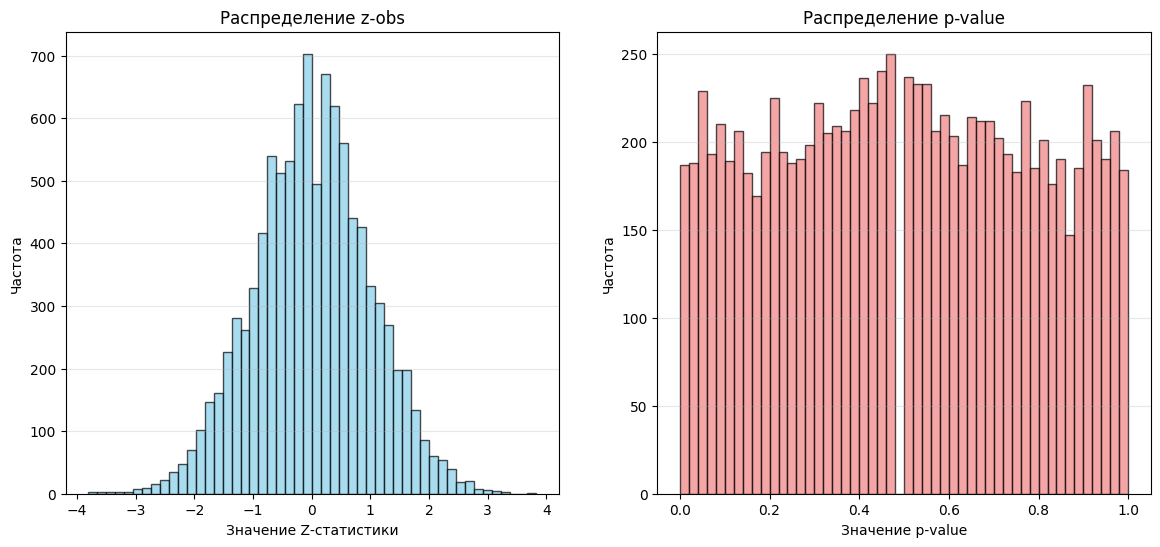

In [59]:
# ваш код
N = 10000

values = []
for i in range(N):
    z_obs, pval = asy_mean_test(*gen_sample(10**3, 0, 0.2))
    values.append((z_obs, pval))  

z_obs_list_norm = [item[0] for item in values]
pval_list_norm = [item[1] for item in values]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.hist(z_obs_list_norm, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_title('Распределение z-obs')
ax1.set_xlabel('Значение Z‑статистики')
ax1.set_ylabel('Частота')
ax1.grid(axis='y', alpha=0.3)

ax2.hist(pval_list_norm, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
ax2.set_title('Распределение p-value')
ax2.set_xlabel('Значение p‑value')
ax2.set_ylabel('Частота')
ax2.grid(axis='y', alpha=0.3)

plt.show()

Правда ли, что распределение `pvalue` оказалось равномерным на отрезке $[0;1]$? Какое у распределения `z_obs` математическое ожидание? Попытайтесь понятными словами пояснить, почему распределения оказались именно такими.

__Ответ:__

Z_obs - по ЦПТ стремится иметь нормальное распределение, что мы и видим на графике. Pvalue - можно сказать около равномерно, но в целом да потому что pvalue получается вычитанием из 1 вероятностей - то есть все значения у нас будут лежать в отрезке [0,1] - а также надо учитывать что z_obs по цпт стремиться иметь нормальное распределение. Матожидание z_obs равно 0, так это по ЦПТ это N(0,1).

__в) [1 балл]__ Предположим, что верна альтернативная гипотеза. Доля в тестовой (treatment) выборке оказалась на $20\%$ больше, чем в контрольной. Как при верности нулевой гипотезы будут распределены `pvalue` и `z_obs`?  

С помощью симуляций сгенерируйте $10^4$ выборок размера $1000$, постройте две гистограммы и прокомментируйте получившиеся результаты.

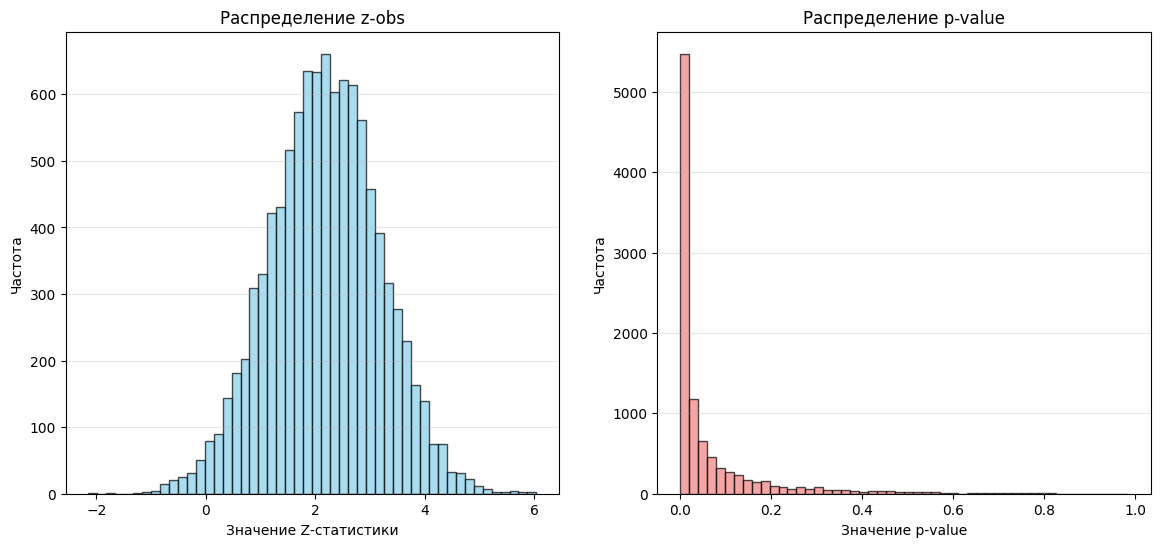

In [60]:
# ваш код
N = 10000

values = []
for i in range(N):
    z_obs, pval = asy_mean_test(*gen_sample(10**3, 0.2, 0.2))
    values.append((z_obs, pval))  

z_obs_list20 = [item[0] for item in values]
pval_list20 = [item[1] for item in values]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.hist(z_obs_list20, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_title('Распределение z-obs')
ax1.set_xlabel('Значение Z‑статистики')
ax1.set_ylabel('Частота')
ax1.grid(axis='y', alpha=0.3)

ax2.hist(pval_list20, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
ax2.set_title('Распределение p-value')
ax2.set_xlabel('Значение p‑value')
ax2.set_ylabel('Частота')
ax2.grid(axis='y', alpha=0.3)

plt.show()

А как будут выглядеть результаты, если доля в тестовой выборке больше на $40\%$? Проведите симуляции.

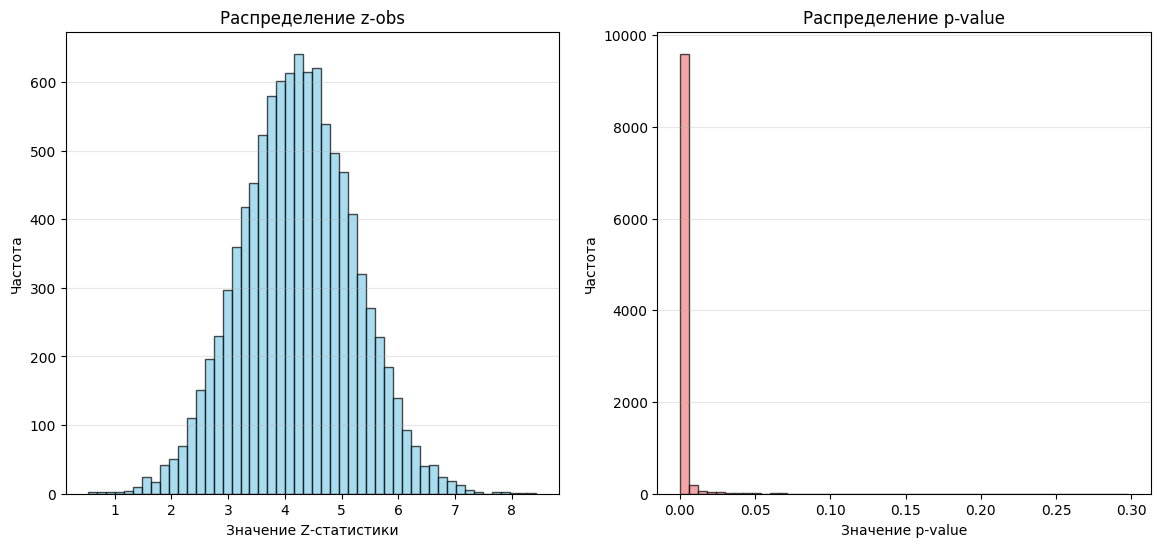

In [61]:
# ваш код
N = 10000

values = []
for i in range(N):
    z_obs, pval = asy_mean_test(*gen_sample(10**3, 0.4, 0.2))
    values.append((z_obs, pval))  

z_obs_list40 = [item[0] for item in values]
pval_list40 = [item[1] for item in values]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.hist(z_obs_list40, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_title('Распределение z-obs')
ax1.set_xlabel('Значение Z‑статистики')
ax1.set_ylabel('Частота')
ax1.grid(axis='y', alpha=0.3)

ax2.hist(pval_list40, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
ax2.set_title('Распределение p-value')
ax2.set_xlabel('Значение p‑value')
ax2.set_ylabel('Частота')
ax2.grid(axis='y', alpha=0.3)

plt.show()

Правда ли, что распределение `pvalue` оказалось равномерным на отрезке $[0;1]$? Какое у распределения `z_obs` математическое ожидание? Попытайтесь понятными словами пояснить, почему распределения оказались именно такими.

__Ответ:__
Нет, в данном случае pvalue неравномерно - так как нулевая гипотеза неверна, есть эффект. На графике pvalue распределение скошено влево, а z_статистика продолжает имеет нормальное распределение - но значения выросли и оно больше не колеблется вокругл нуля, мат ожидание - где то 4, исходя из графика, поэтому и pvalue становится скошен влево.

з
__г) [1 балл]__ Обычно, перед началом эксперимента, мы фиксируем ошибку первого рода, вероятность отвергнуть нулевую гипотезу, когда она на самом деле верна,  

$$\alpha = \mathbb{P}(H_A \text{ выбрана} \mid H_0 \text{ верна}).$$

Дальше мы принимаем решение, о том, какую гипотезу выбрать, сравнивая `z_obs` с $z_{1 - \alpha},$ либо `pvalue` с $\alpha$ (напомню что мы делаем симуляции для правосторонней альтернативы, поэтому $\alpha$ не надо делить на два).

Давайте проверим для конкретного $\alpha$, что это правда работает. Выберите любое разумное значение $\alpha$. С помощью симуляций сгенерируйте $10^4$ выборок размера $1000$ при верности нулевой гипотезы. Проверьте эти гипотезы и оцените получившееся значение $\alpha$. Правда ли, что оно оказалось равно заявленному значению?

__P.S.__ в идеале, тут надо воспользоваться уже проделанными выше симуляциями.

In [62]:
# ваш кодa
alpha = 0.05

rejections_pval = sum(1 for pval in pval_list_norm if pval < alpha)
alpha_pval = rejections_pval / len(pval_list_norm)
print(alpha_pval)

z_alpha = stats.norm.ppf(1-alpha)
rejections_z = sum(1 for z_obs in z_obs_list_norm if z_obs > z_alpha)
alpha_z = rejections_z / len(z_obs_list_norm)
print(alpha_z)


0.0502
0.0502


Кроме ошибки первого рода есть ещё и ошибка второго рода, вероятность остаться с нулевой гипотезой, когда верна альтернатива,

$$\beta = \mathbb{P}(H_0 \text{ выбрана} \mid H_A \text{ верна}).$$

Давайте предположим, что доля в тестовой (treatment) выборке оказалась на $20\%$ больше, чем в контрольной. С помощью симуляций того же самого объёма оцените, чему равна $\beta$.

__P.S.__ в идеале, тут надо воспользоваться уже проделанными выше симуляциями.

In [63]:
# ваш код
beta_pval_sum = sum(1 for pval in pval_list20 if pval >= alpha)
beta_pval = beta_pval_sum / len(pval_list20)
print(beta_pval)

beta_z_sum = sum(1 for z_obs in z_obs_list20 if z_obs <= z_alpha)
beta_z = beta_z_sum / len(z_obs_list20)

print(beta_z)

0.2958
0.2958


Теперь доля в тестовой выборке оказалась на $40\%$ больше, чем в контрольной. Чем равна $\beta$ здесь?

In [64]:
# ваш код
beta_pval_sum = sum(1 for pval in pval_list40 if pval >= alpha)
beta_pval = beta_pval_sum / len(pval_list40)
print(beta_pval)

beta_z_sum = sum(1 for z_obs in z_obs_list40 if z_obs <= z_alpha)
beta_z = beta_z_sum / len(z_obs_list40)

print(beta_z)

0.005
0.005


Что с ошибкой второго рода происходит при росте эффекта? Что происходит с ней, если при проверке гипотезы взять более маленькое $\alpha$?

__Ответ:__
В первом случае ошибка второго рода уменьшается, во втором случае ошибка второго рода увеличивается.

__д) [1 балл]__ Ошибки $\alpha$ и $\beta$ связаны между собой. Чем выше, при фиксированном размере выборки и эффекта мы делаем одну, тем ниже другая. Давайте попробуем в рамках проделанных выше симуляций нарисовать взаимосвязь между ошибками.

Выше, для оценки $\beta$ вы сравнивали вектор `pval` с зафиксированным значением `alpha`.  Переберите `alpha` по циклу от 0 до 1 с шагом 0.01 и оцените для каждого значения `alpha` значение `beta`.

Нарисуйте получившуюся взаимосвязь на графике для эффекта в 20% и 40%. Какая из кривых идёт ниже?

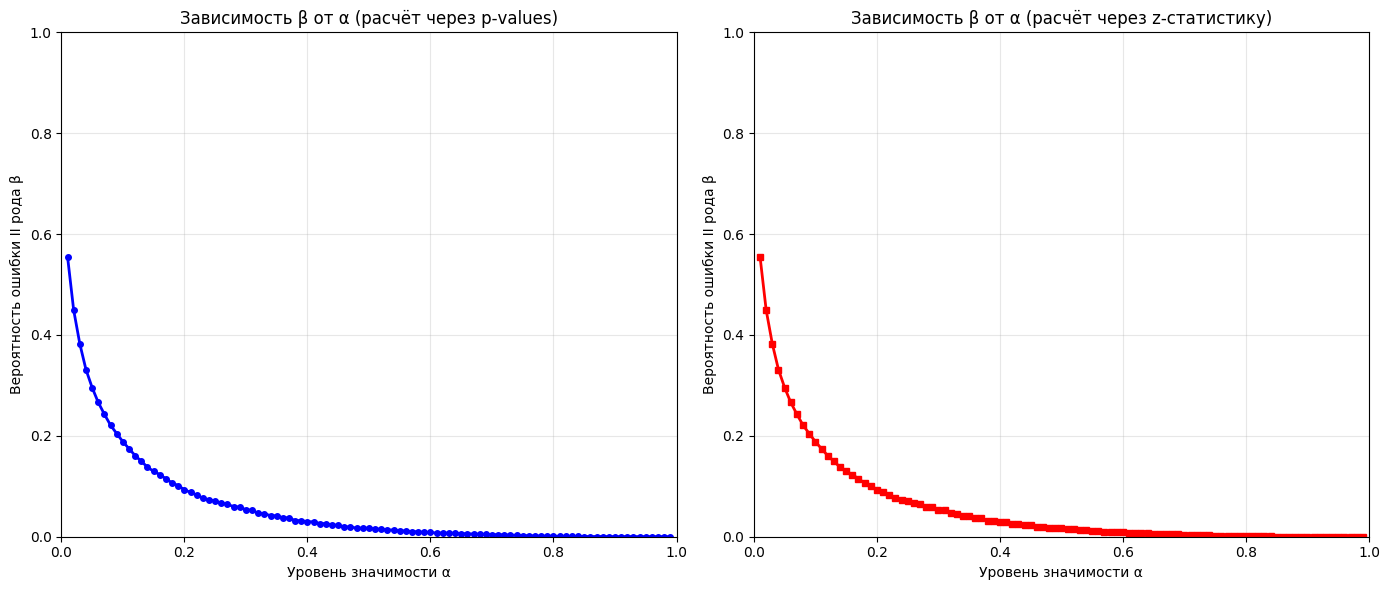

In [65]:
# ваш код
step = 0.01
pvals_beta = []
zvals_beta = []
alphas = [] 

for i in range(1, 100):
    alpha = step * i 
    alphas.append(alpha)
    
    beta_pval_sum = sum(1 for pval in pval_list20 if pval >= alpha)
    beta_pval = beta_pval_sum / len(pval_list20)
    pvals_beta.append(beta_pval)
    z_critical = stats.norm.ppf(1 - alpha)
    beta_z_sum = sum(1 for z_obs in z_obs_list20 if z_obs <= z_critical)
    beta_z = beta_z_sum / len(z_obs_list20)
    zvals_beta.append(beta_z)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(alphas, pvals_beta, color='blue', linewidth=2, marker='o', markersize=4)
ax1.set_xlabel('Уровень значимости α')
ax1.set_ylabel('Вероятность ошибки II рода β')
ax1.set_title('Зависимость β от α (расчёт через p‑values)')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

ax2.plot(alphas, zvals_beta, color='red', linewidth=2, marker='s', markersize=4)
ax2.set_xlabel('Уровень значимости α')
ax2.set_ylabel('Вероятность ошибки II рода β')
ax2.set_title('Зависимость β от α (расчёт через z‑статистику)')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()   

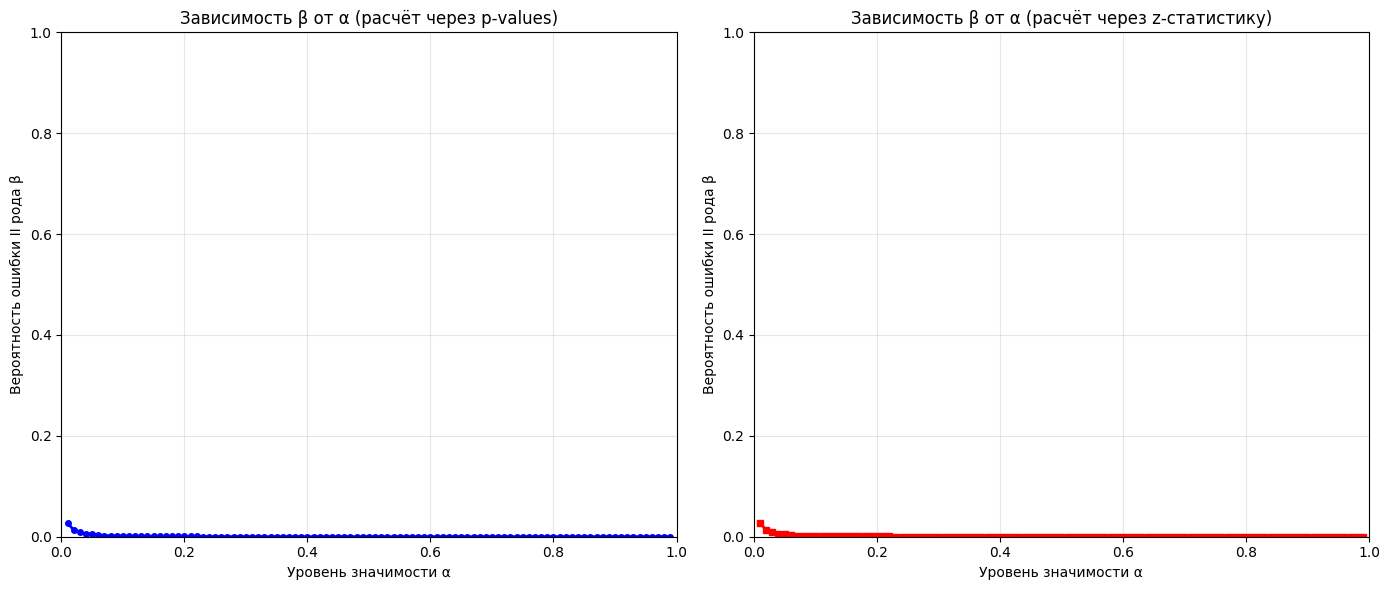

In [66]:
# ваш код
step = 0.01
pvals_beta = []
zvals_beta = []
alphas = [] 

for i in range(1, 100):
    alpha = step * i 
    alphas.append(alpha)
    
    beta_pval_sum = sum(1 for pval in pval_list40 if pval >= alpha)
    beta_pval = beta_pval_sum / len(pval_list40)
    pvals_beta.append(beta_pval)
    z_critical = stats.norm.ppf(1 - alpha)
    beta_z_sum = sum(1 for z_obs in z_obs_list40 if z_obs <= z_critical)
    beta_z = beta_z_sum / len(z_obs_list40)
    zvals_beta.append(beta_z)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(alphas, pvals_beta, color='blue', linewidth=2, marker='o', markersize=4)
ax1.set_xlabel('Уровень значимости α')
ax1.set_ylabel('Вероятность ошибки II рода β')
ax1.set_title('Зависимость β от α (расчёт через p‑values)')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

ax2.plot(alphas, zvals_beta, color='red', linewidth=2, marker='s', markersize=4)
ax2.set_xlabel('Уровень значимости α')
ax2.set_ylabel('Вероятность ошибки II рода β')
ax2.set_title('Зависимость β от α (расчёт через z‑статистику)')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()   

Нарисуйте точно такую же кривую для ситуации, когда была верна нулевая гипотеза.

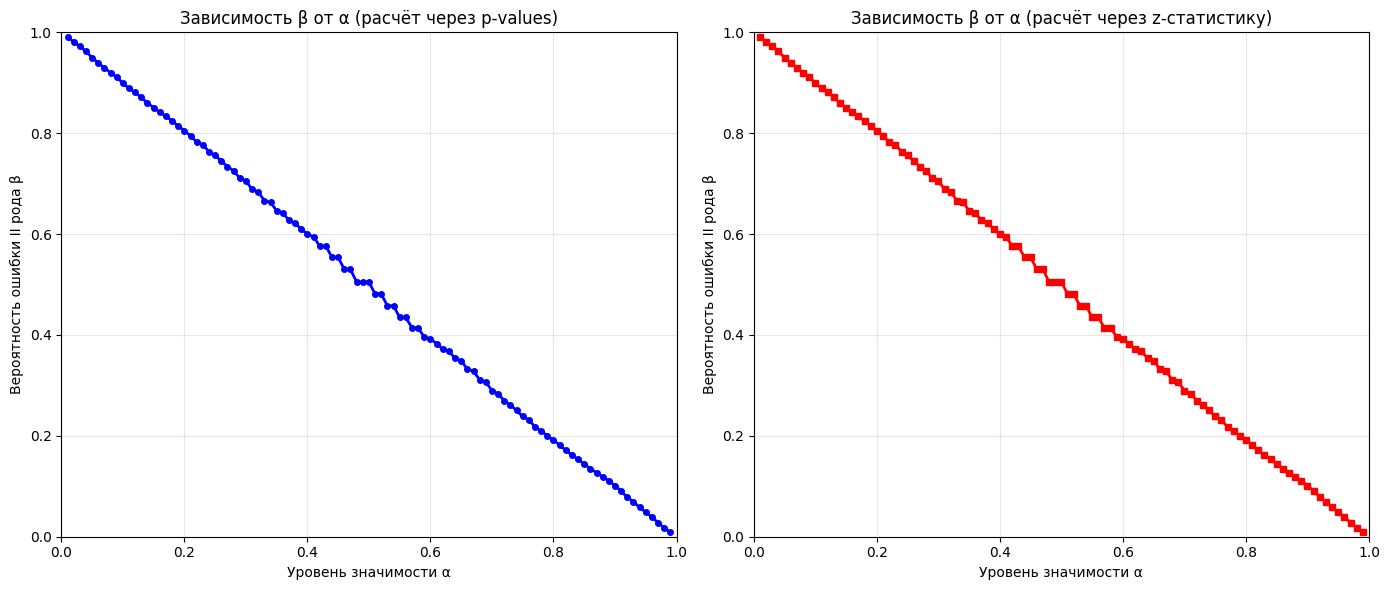

In [67]:
# ваш код
step = 0.01
pvals_beta = []
zvals_beta = []
alphas = [] 

for i in range(1, 100):
    alpha = step * i 
    alphas.append(alpha)
    
    beta_pval_sum = sum(1 for pval in pval_list_norm if pval >= alpha)
    beta_pval = beta_pval_sum / len(pval_list_norm)
    pvals_beta.append(beta_pval)
    z_critical = stats.norm.ppf(1 - alpha)
    beta_z_sum = sum(1 for z_obs in z_obs_list_norm if z_obs <= z_critical)
    beta_z = beta_z_sum / len(z_obs_list_norm)
    zvals_beta.append(beta_z)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(alphas, pvals_beta, color='blue', linewidth=2, marker='o', markersize=4)
ax1.set_xlabel('Уровень значимости α')
ax1.set_ylabel('Вероятность ошибки II рода β')
ax1.set_title('Зависимость β от α (расчёт через p‑values)')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

ax2.plot(alphas, zvals_beta, color='red', linewidth=2, marker='s', markersize=4)
ax2.set_xlabel('Уровень значимости α')
ax2.set_ylabel('Вероятность ошибки II рода β')
ax2.set_title('Зависимость β от α (расчёт через z‑статистику)')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()   

Вместо осей $(\alpha, \beta)$ обычно такой график рисуют в осях $(\alpha, 1 - \beta)$. Давайте построим его и проинтерпретируем.

In [68]:
def plot_pvalue_distribution(dict_pvalues):
    xseq = np.linspace(0, 1, 1000)

    for key, pvalues in dict_pvalues.items():
        yseq = [np.mean(pvalues < x) for x in xseq]
        plt.plot(xseq, yseq, label=key)

    plt.plot([0, 1], [0, 1], '--k', alpha=0.8)
    plt.title('Распределение p-value/ROC-кривая', size=16)
    plt.xlabel('alpha', size=12)
    plt.ylabel('1 - beta', size=12)
    plt.legend(fontsize=12)
    plt.grid()

Заполните пропуски в коде ниже, чтобы для нашего АБ-теста отрисовались ROC-кривые.

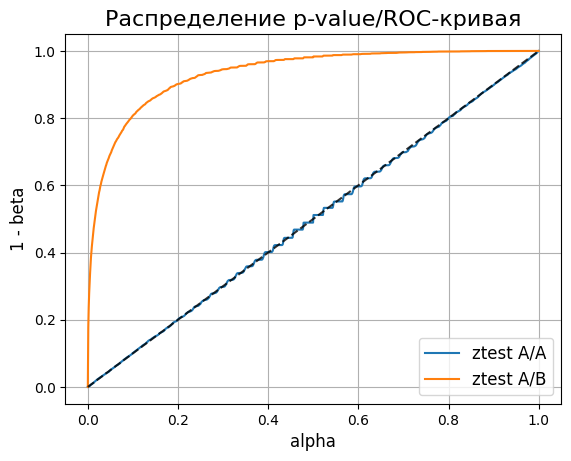

In [69]:
n_sim = 10**4
sample_size = 1000

dict_pvalues = defaultdict(list)
for _ in range(n_sim):

    x_control, x_treatment = gen_sample(sample_size, 0.2, 0.2)
    z_obs_ab, pval_ab = asy_mean_test(x_control, x_treatment)

    # сгенерируем ещё одну тестовую выборку, чтобы убедиться, что в случае когда выборки совпали,
    # наш тест работает корректно и не находит разницу
    x_control_again, _ = gen_sample(sample_size, 0, 0.2) 
    z_obs_aa, pval_aa = asy_mean_test(x_control, x_control_again)

    dict_pvalues['ztest A/A'].append(pval_aa)
    dict_pvalues['ztest A/B'].append(pval_ab)

plot_pvalue_distribution(dict_pvalues)

Получившийся график можно проинтерпретировать двумя способами. Мы много-много раз проводим АБ-тест. В начале теста мы зафиксировали какую-то $\alpha$ и дальше проверяем кучу гипотез.

1. Линия `ztest A/A` это функция распределения pvalue при верности нулевой гипотезы. Оно было равномерным, мы двигаем $\alpha$ по оси $OX$ и оцениваем $\mathbb{P}(\text{pvalue} \le \alpha) = F(\alpha)$.  

По аналогии, линия `ztest A/B` это функция распределения pvalue при верности альтернативной гипотезы.

2. Линию `ztest A/B` можно проинтерпретировать как ROC-кривую. Если вы уже знаете про задачу классификации из машинного обучения, то это ровно оно. Полнота это $1 - \beta$, то есть то, сколько верных альтернативных гипотез мы найдём, если будем использовать наш АБ-тест, FPR это $\alpha$, то есть то, сколько верных нулевых гипотез мы заберём с собой в альтернативные. Эту величину мы определяем до старта эксперимента.

> Важно: если вы не поняли интерпретацию из пункта 2, просто забейте. Заботаете МО, поймёте. Интерпретацию из пункта 1 должны понять все. Если вы её не поняли, время напрячься и подумать ещё разок.

__Что для нас важно:__

- Чем выпуклее график, тем лучше мы находим эффект и процедура проверки гипотезы работае корректно;
- Чем больше у нас наблюдений тем выпуклее график;
- Чем сильнее в тестовой выборке подскакивает $p_t$ при изменениях, тем легче нам найти эффект и тем выпуклее график;
- Если $p_t$ подскочило на очень маленькую величину, нам сложнее найти это изменение, и график будет менее выпуклым;
- Чем меньше в выборках дисперсия, тем выпуклее график.

__е) [2 балла]__ При верности альтернативной гипотезы, постройте ROC-кривые из пункта выше для разного числа наблюдений в выборке: 10, 100, 1000, 10000 при любом фиксированном эффекте.

C:\Users\Альберт\AppData\Local\Temp\ipykernel_3036\3215879573.py:11: RuntimeWarning: invalid value encountered in scalar divide
  z_obs = (mean2 - mean1) / se


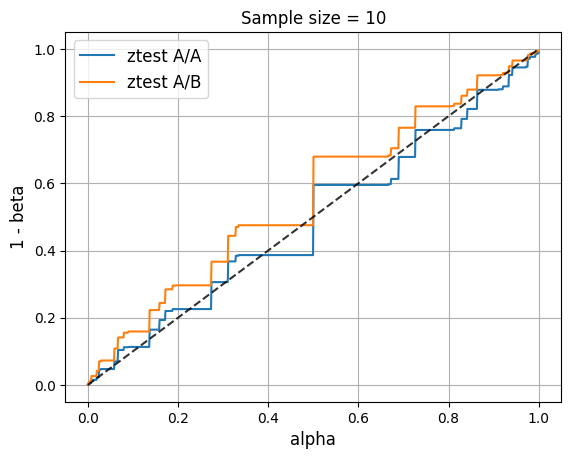

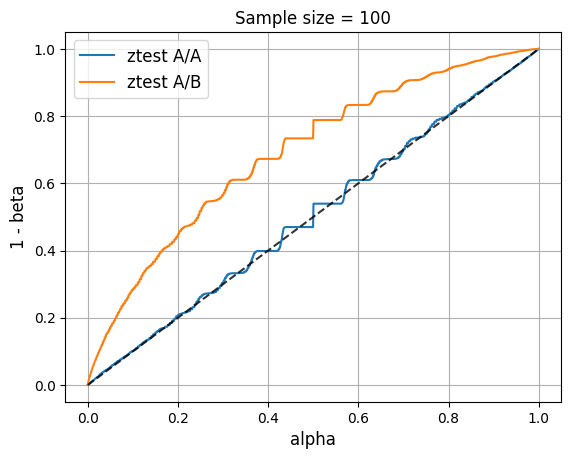

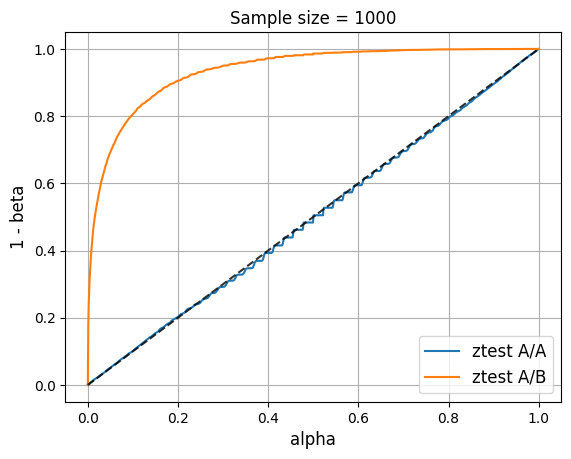

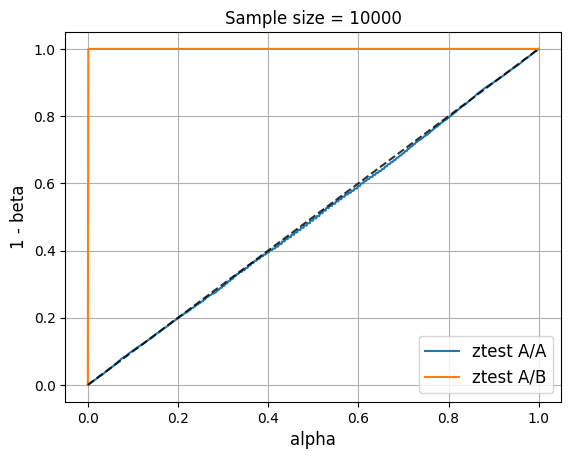

In [70]:
# ваш код
n_sim = 10**4
sample_sizes = [10, 100, 1000, 10000]

for sample in sample_sizes:
    dict_pvalues_arr = defaultdict(list) 

    for _ in range(n_sim):
    
        x_control, x_treatment = gen_sample(sample, 0.2, 0.2)
        z_obs_ab, pval_ab = asy_mean_test(x_control, x_treatment)
    
        # A/A тест
        x_control_again, _ = gen_sample(sample, 0, 0.2) 
        z_obs_aa, pval_aa = asy_mean_test(x_control, x_control_again)
    
        dict_pvalues_arr['ztest A/A'].append(pval_aa)
        dict_pvalues_arr['ztest A/B'].append(pval_ab)
    
    plot_pvalue_distribution(dict_pvalues_arr)
    plt.title(f'Sample size = {sample}')
    plt.show()

__ё) [1 балл]__ Количество наблюдений, ошибка 1 и 2 рода, размер эффекта, который мы ищем и дисперсия в выборках связаны между собой. Для некоторых критериев проверки гипотез можно вывести формулы, которые их связывают.

В данном случае, формула для расчета числа наблюдений _для одной группы_ выглядит вот так:

$$
n_{\text{one group}} = \frac{(\sigma_A^2 + \sigma_B^2) \cdot (z_{1-\frac{\alpha}{2}} + z_{1-\beta})^2}{MDE^2},
$$

В приложении Яндекс.Такси в конце поездки вылезают рандомные опросники. В одном из опросников задаётся вопрос «А вы пристёгивались, когда ехали?»

В России, в день, в Такси происходит 1 миллион заказов. Вопрос про ремни задаётся рандомным 10% пользователей, закончивших поездку. Пользователь не игнорирует опросник и отвечает на него да или нет с вероятностью 5% (цифры взяты из головы и не отражают реальную статистику).

Менеджер Екатерина хочет сделать так, чтобы когда пассажир садится в машину, Алиса просила его пристегнуться. Хочется замерить, какой эффект это даст на пристёгивания. Станут ли люди чаще пристёгиваться. Замерять мы это будем опросником. Сейчас 10% пользователей говорят, что пристегнулись.

Екатерина пришла к вам и между вами состоялся следующий диалог:

- Хочу АБ-тест с разбивкой 50 на 50.
- Какие ошибки 1 и 2 рода хочешь?
- Нулевые.
- Нам надо бесконечно наблюдений, готова столько ждать?
- Нет.
- На сколько мы хотим, чтобы выросла доля ответов да?
- Если подрастёт хотябы на процент, будет круто.
- То есть если меньше процента, такой эффект считаем неудачей и отсутствием изменения?
- Да.
- Давай я нарисую тебе табличку с разными ошибками, а внутри на пересечении напишу сколько дней надо ждать, чтобы найти такой минимальный эффект.
- Давай, по ней и примем решение.

Нарисуйте для Екатерины такую табличку. Не забудьте перевести общее количество наблюдений в дни.

In [71]:
# Ваш код
p_A = 0.10
p_B = 0.11
MDE = 0.01

var_A = p_A * (1 - p_A)
var_B = p_B * (1 - p_B)

obs_per_day_group = 2500

alphas = [0.01, 0.05, 0.1]
betas = [0.01, 0.05, 0.1, 0.2]

table = pd.DataFrame(index=alphas, columns=betas)

for alpha in alphas:
    for beta in betas:
        z_alpha = norm.ppf(1 - alpha / 2)
        z_beta = norm.ppf(1 - beta)
        n = ((var_A + var_B) * (z_alpha + z_beta) ** 2) / (MDE ** 2)
        days = np.ceil(n / obs_per_day_group)
        table.loc[alpha, beta] = int(days)

table
# не засчитывайте - догнал как все это добить и прогнать только с LLM :(

,0.01,0.05,0.10,0.20
0.01,19,14,12,9
0.05,14,10,8,6
0.10,12,9,7,5


__ж) [1 балл]__ Попробуем сломать наш АБ-тест. Когда мы используем z-тест, мы размышляем в терминах центральной предельной теоремы. Тест будет работать, если выполнены предпосылки ЦПТ:

- Наблюдения независимо одинаково распределены
- В данных нет выборосов, дисперсия конечная
- Данных много

Давайте сломаем одно из условий и попробуем собрать выборку из [распределения Парето](https://ru.wikipedia.org/wiki/Распределение_Парето).

In [72]:
def gen_sample(n_obs, effect, b=0.5):
    x_control = stats.pareto(b=b).rvs(n_obs)
    x_treatment = stats.pareto(b=b).rvs(n_obs)
    x_treatment = (1 + effect) * x_treatment
    return x_control, x_treatment

Отрисуйте ROC-кривые для $b=3$, $b=1$, $b=0.5$

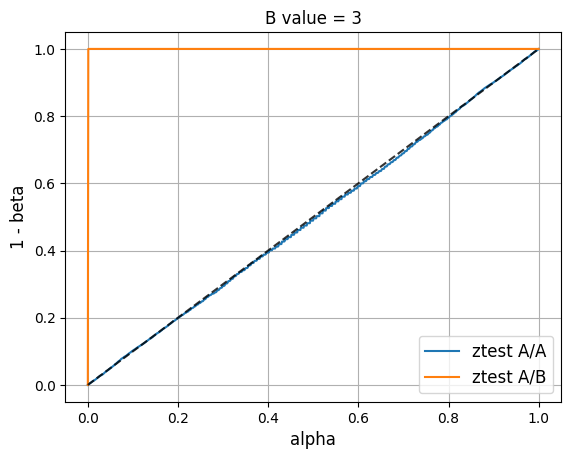

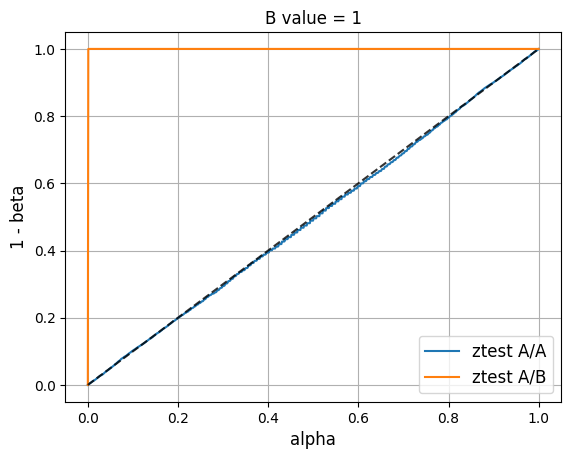

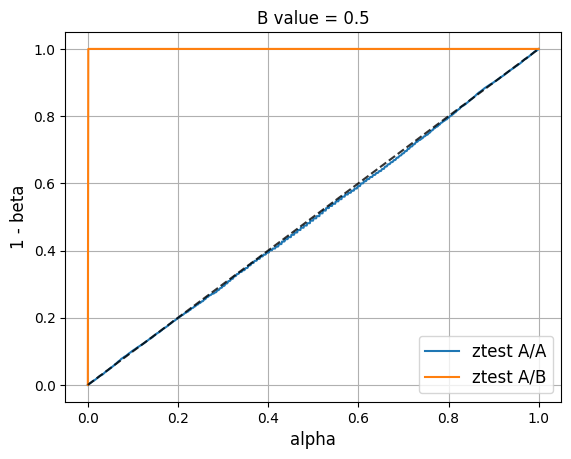

In [73]:
# ваш код
n_sim = 10**4
sample_size = 1000
b_arr = [3,1,0.5]
dict_pvalues = defaultdict(list)
for b in b_arr:
    for _ in range(n_sim):
    
        x_control, x_treatment = gen_sample(sample_size, 0.2, 3)
        z_obs_ab, pval_ab = asy_mean_test(x_control, x_treatment)
    
        # сгенерируем ещё одну тестовую выборку, чтобы убедиться, что в случае когда выборки совпали,
        # наш тест работает корректно и не находит разницу
        x_control_again, _ = gen_sample(sample_size, 0, 3) 
        z_obs_aa, pval_aa = asy_mean_test(x_control, x_control_again)
    
        dict_pvalues['ztest A/A'].append(pval_aa)
        dict_pvalues['ztest A/B'].append(pval_ab)
    
    plot_pvalue_distribution(dict_pvalues_arr)
    plt.title(f'B value = {b}')
    plt.show()

Возьмите при каждом $b$ одну выборку, нарисуйте для неё гистограмму и посмотрите как обстоят дела с выбросами.

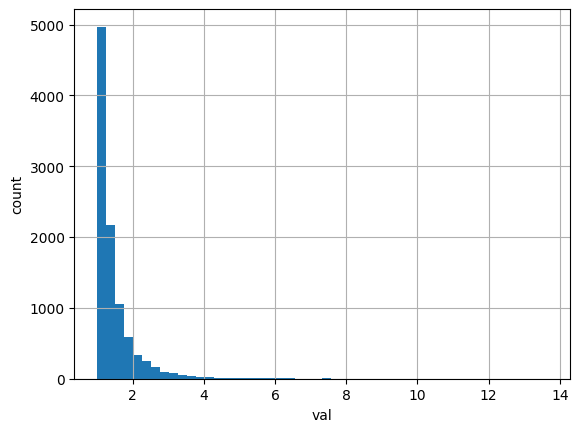

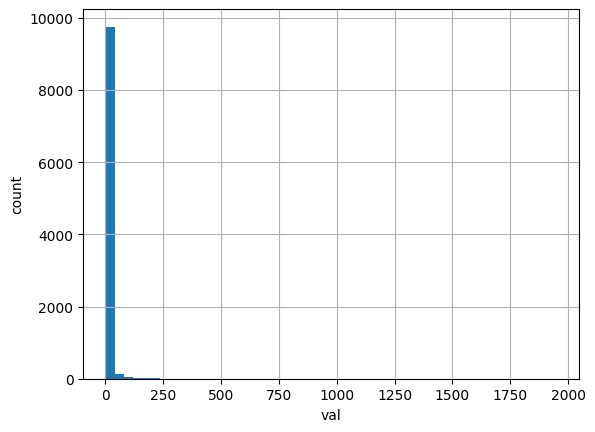

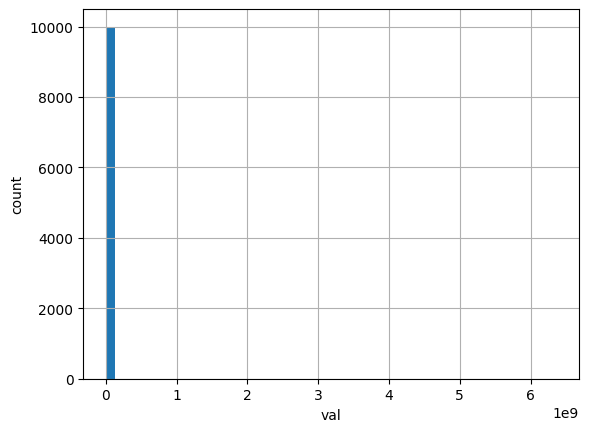

In [76]:
# ваш код
sample_size = 10000
b_arr = [3, 1, 0.5]

for b in b_arr:
    x_control, x_treatment = gen_sample(sample_size, 0.2, b)
    
    plt.figure()
    plt.hist(x_control, bins=50)
    plt.xlabel('val')
    plt.ylabel('count')
    plt.grid()
    plt.show()

У распределения Парето не всегда существует дисперсия. Это ломает предпосылки ЦПТ и АБ-тест разваливается.

Возникает вполне резонный вопрос: а что делать в таких ситуациях? Есть несколько дорог.

- Во-первых, можно отвязаться от математического ожидания и поработать с медианой. Для неё тоже можно вывести асимптотическое распределение с помощью дельта-метода.
- Во-вторых, можно попробовать другие техники проверки гипотез. Например, бутстрап и непараметрические критерии.

Об этом мы и будем говорить на следующих парах.